In [1]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('../data/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())


Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [2]:
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])


Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

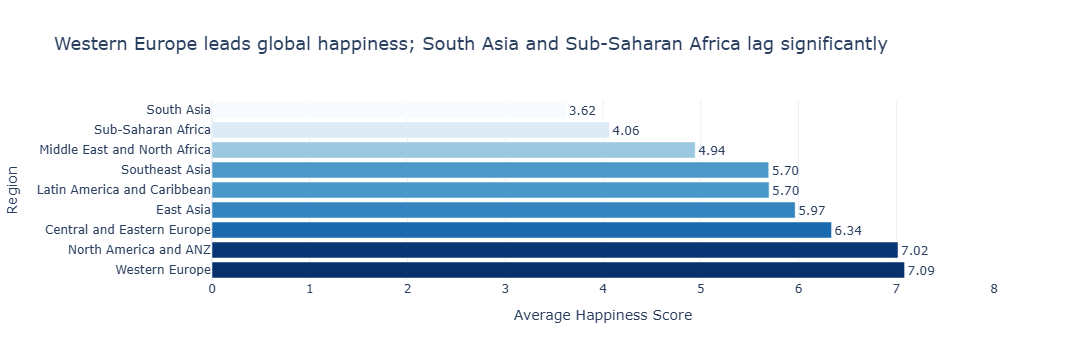

In [17]:
import plotly.express as px

# Step 1: Compute average happiness score by region
# We sort ascending here, but Plotly flips it on the Y-axis unless we specify otherwise
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score', ascending=True))

# Step 2: Build the chart to match the screenshot
fig1 = px.bar(region_avg, 
              x='Happiness_Score', 
              y='Region',
              orientation='h',
              # Matching the specific title from your screenshot
              title='Western Europe leads global happiness; South Asia and Sub-Saharan Africa lag significantly',
              labels={'Happiness_Score': 'Average Happiness Score', 'Region': 'Region'},
              template='plotly_white',
              color='Happiness_Score',
              # Adding text labels on the bars and formatting to 2 decimal places
              text='Happiness_Score',
              color_continuous_scale='Blues')

# --- Refined Styling to match the UI ---

# 1. Format the text labels to appear outside the bars
fig1.update_traces(texttemplate='%{text:.2f}', textposition='outside')

# 2. Ensure the highest value is at the top (Reversing the Y-axis)
fig1.update_yaxes(autorange="reversed")

# 3. Match the X-axis range and hide the color bar (legend) 
fig1.update_layout(
    xaxis_range=[0, 8],
    coloraxis_showscale=False, # Removes the color gradient bar on the right
    showlegend=False,
    title_font_size=18
)

fig1.show()

Global average: 5.81


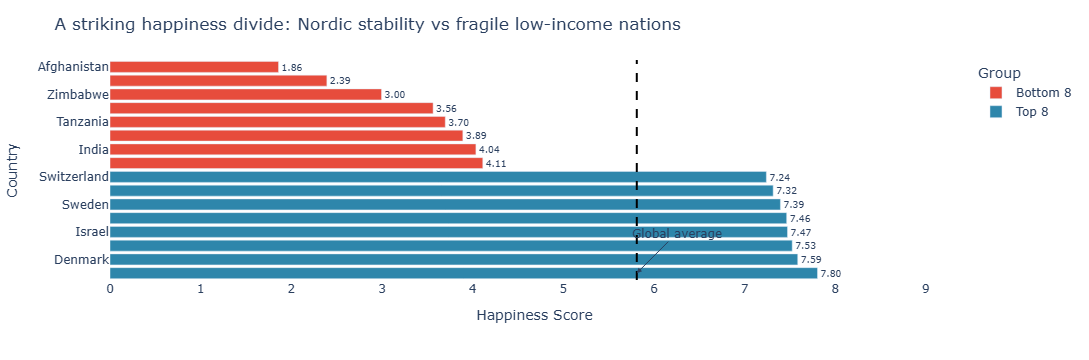

In [19]:
# Task 2: Top 8 vs. Bottom 8 contrast
# ------------------------------------

# Step 1: Get top and bottom countries
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")

# Step 2: Build your chart
# YOUR CODE HERE

import plotly.express as px

fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    orientation='h',
    color='Group',
    text='Happiness_Score',
    color_discrete_map={
        'Top 8': '#2E86AB',      # calm blue
        'Bottom 8': '#E74C3C'    # strong red
    }
)

# Show values on bars
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

# Layout styling
fig.update_layout(
    title="A striking happiness divide: Nordic stability vs fragile low-income nations",
    xaxis_title="Happiness Score",
    yaxis_title="Country",
    plot_bgcolor='white',
    legend_title="Group"
)

# Zero baseline (required rule)
fig.update_xaxes(range=[0, combined['Happiness_Score'].max() * 1.2], zeroline=True)

# Add global average reference line (stretch goal)
fig.add_vline(
    x=global_avg,
    line_width=2,
    line_dash="dash",
    line_color="black"
)

fig.add_annotation(
    x=global_avg,
    y=combined['Country'].iloc[-1],
    text="Global average",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40
)

# Improve ordering for readability
fig.update_yaxes(autorange='reversed')

fig.show()

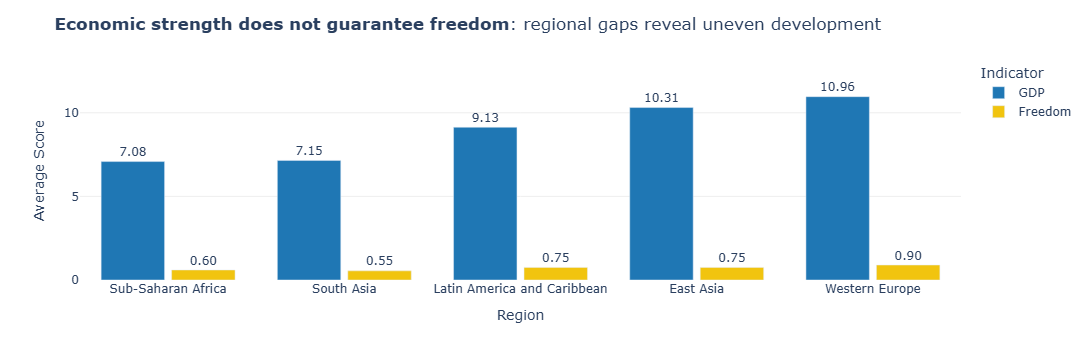

In [21]:
# ------------------------------------
# Step 4: Create grouped bar chart
# ------------------------------------
import plotly.express as px

fig = px.bar(
    df_melted,
    x='Region',
    y='Score',
    color='Indicator',
    barmode='group',
    text='Score',
    color_discrete_map={
        'GDP': '#1f77b4',      # strong blue
        'Freedom': '#f1c40f'   # <--- Changed from green to yellow
    })

# ------------------------------------
# Step 5: Styling (professional quality)
# ------------------------------------
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.update_layout(
    title="<b>Economic strength does not guarantee freedom</b>: regional gaps reveal uneven development",
    xaxis_title="Region",
    yaxis_title="Average Score",
    plot_bgcolor='white',
    legend_title="Indicator",
    # Added formatting to make the bars pop against the white background
    bargap=0.2, 
    bargroupgap=0.1
)

# Zero baseline requirement with a bit of headroom for the text labels
fig.update_yaxes(
    range=[0, df_melted['Score'].max() * 1.2], 
    zeroline=True, 
    showgrid=True, 
    gridcolor='#eeeeee'
)

fig.show()